In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [ ]:
# Load and prepare data
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
df['Order Date'] = pd.to_datetime(df['Order Date'])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# **TASK 1**

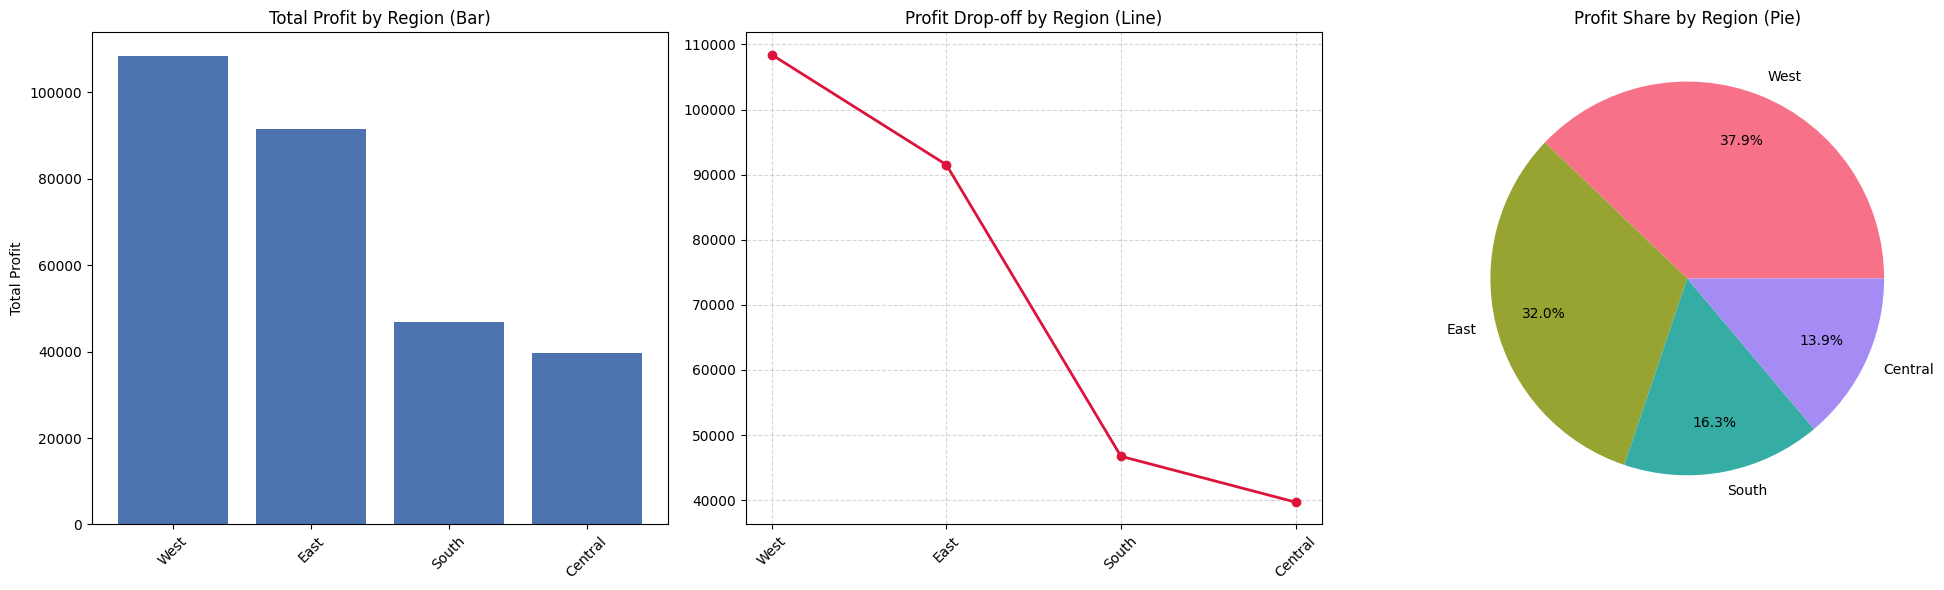

In [ ]:
# Group by a categorical column and sum a numerical column
region_profit = df.groupby('Region')['Profit'].sum().reset_index()

# Sort values so the charts display in descending order of profit
region_profit = region_profit.sort_values(by='Profit', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Bar Chart
axes[0].bar(region_profit['Region'], region_profit['Profit'], color='#4C72B0')
axes[0].set_title('Total Profit by Region (Bar)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Total Profit')

# Line/Point Chart (Connecting categorical points to show drop-off)
axes[1].plot(region_profit['Region'], region_profit['Profit'], marker='o', color='#DC143C', linewidth=2)
axes[1].set_title('Profit Drop-off by Region (Line)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Custom formatting function for the pie chart
def label_filter(pct):
    return f'{pct:.1f}%' if pct > 3.0 else ''

# Pie Chart
colors = sns.color_palette("husl", len(region_profit))
axes[2].pie(
    region_profit['Profit'],
    labels=region_profit['Region'],
    autopct=label_filter,
    colors=colors,
    pctdistance=0.75,
    textprops={'fontsize': 10}
)
axes[2].set_title('Profit Share by Region (Pie)')

plt.tight_layout()
plt.show()

# **TASK 2**

/tmp/ipykernel_1959/3663189136.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_states, x='State', y='Profit', palette='viridis')


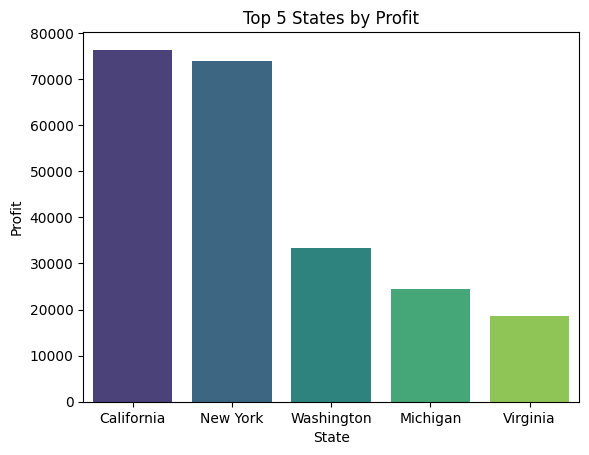

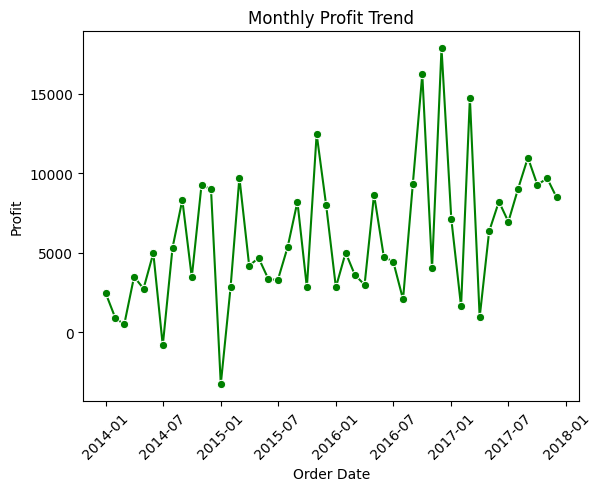

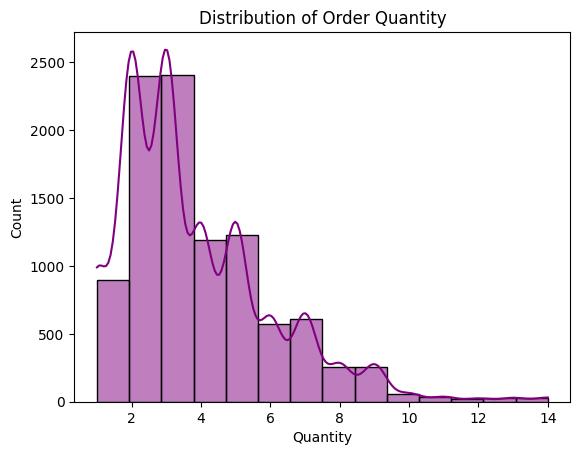

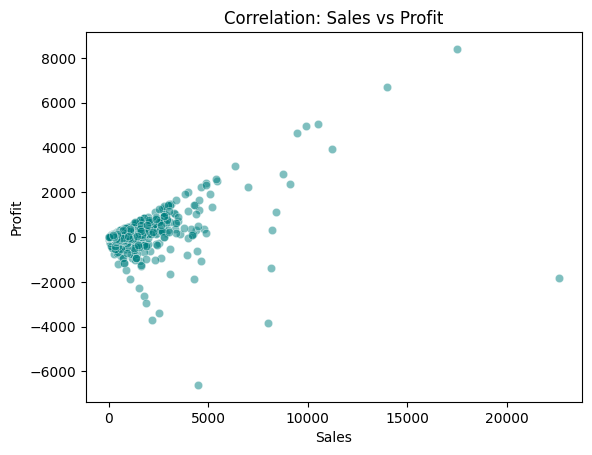

In [ ]:
# 1. Compare total profit across top 5 states (Bar)
top5_states = df.groupby('State')['Profit'].sum().nlargest(5).reset_index()
plt.figure()
sns.barplot(data=top5_states, x='State', y='Profit', palette='viridis')
plt.title('Top 5 States by Profit')

# 2. Profit trend over time (Line)
# Grouping by month for Profit
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum().reset_index()
monthly_profit['Order Date'] = monthly_profit['Order Date'].dt.to_timestamp()

plt.figure()
sns.lineplot(data=monthly_profit, x='Order Date', y='Profit', marker='o', color='green')
plt.xticks(rotation=45)
plt.title('Monthly Profit Trend')

# 3. Distribution of order quantities (Histogram)
plt.figure()
sns.histplot(df['Quantity'], bins=14, kde=True, color='purple')
plt.title('Distribution of Order Quantity')

# 4. Sales vs Profit (Scatter)
plt.figure()
sns.scatterplot(data=df, x='Sales', y='Profit', alpha=0.5, color='teal')
plt.title('Correlation: Sales vs Profit')
plt.show()

# **TASK 3**

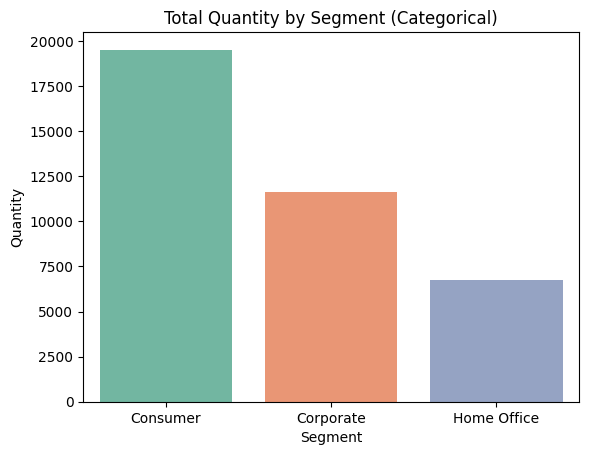

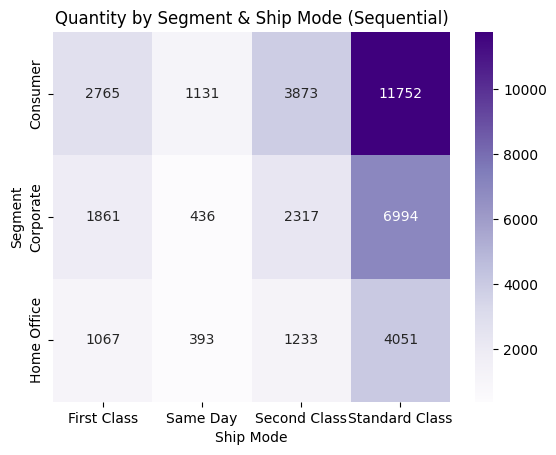

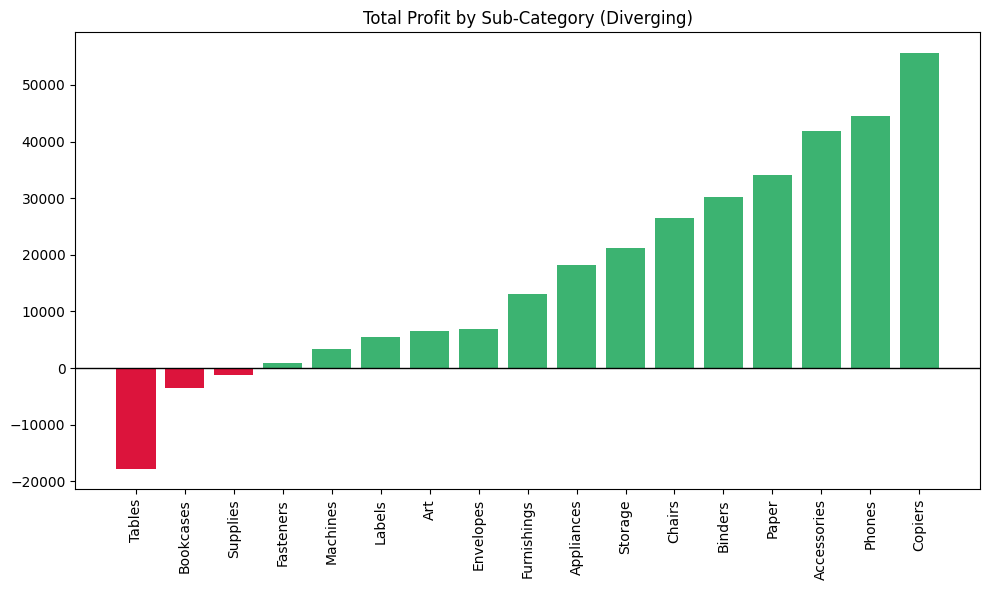

In [ ]:
# (a) Categorical palette
# Changed to analyze total Quantity by Segment
segment_qty = df.groupby('Segment')['Quantity'].sum().reset_index()
sns.barplot(data=segment_qty, x='Segment', y='Quantity', hue='Segment', palette='Set2', legend=False)
plt.title('Total Quantity by Segment (Categorical)')
plt.show()

# (b) Sequential palette
# Changed to analyze Quantity across Segment and Ship Mode
seg_ship = df.pivot_table(index='Segment', columns='Ship Mode', values='Quantity', aggfunc='sum')
sns.heatmap(seg_ship, cmap='Purples', annot=True, fmt='.0f')
plt.title('Quantity by Segment & Ship Mode (Sequential)')
plt.show()

# (c) Diverging Data
# Changed to analyze Profit by Sub-Category (which naturally contains gains and losses)
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()

# Sorting helps emphasize the diverging nature of the data
subcat_profit = subcat_profit.sort_values('Profit')

# Apply diverging colors: crimson for negative, mediumseagreen for positive
subcat_profit['Color'] = subcat_profit['Profit'].apply(lambda x: '#DC143C' if x < 0 else '#3CB371')

# Generate the chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=subcat_profit['Color'])

# Add neutral zero baseline
ax.axhline(0, color='black', linewidth=1)

ax.set_title('Total Profit by Sub-Category (Diverging)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# **TASK 4**

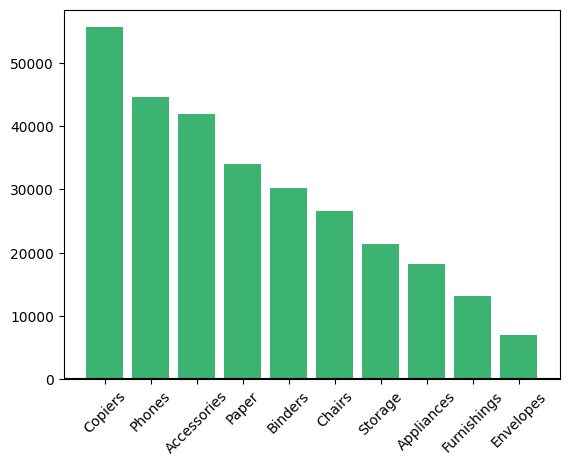

In [ ]:
def get_luminance(hex_color):
    hex_color = hex_color.lstrip('#')
    rgb = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))
    linear = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4 for c in rgb]
    return 0.2126 * linear[0] + 0.7152 * linear[1] + 0.0722 * linear[2]

def get_contrast(c1, c2):
    l1, l2 = get_luminance(c1), get_luminance(c2)
    return (max(l1, l2) + 0.05) / (min(l1, l2) + 0.05)

# (b) Fix using hatching
sub_prof = df.groupby('Sub-Category')['Profit'].sum().nlargest(10).reset_index()
sub_prof['Positive'] = sub_prof['Profit'] > 0

bars = plt.bar(sub_prof['Sub-Category'], sub_prof['Profit'],
               color=['#3CB371' if p else '#DC143C' for p in sub_prof['Positive']])

for bar, is_pos in zip(bars, sub_prof['Positive']):
    if not is_pos:
        bar.set_hatch('//') # Pattern guarantees distinction without color

plt.axhline(0, color='black')
plt.xticks(rotation=45)
plt.show()

# **TASK 5**

/tmp/ipykernel_1959/4036606132.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='Blues')


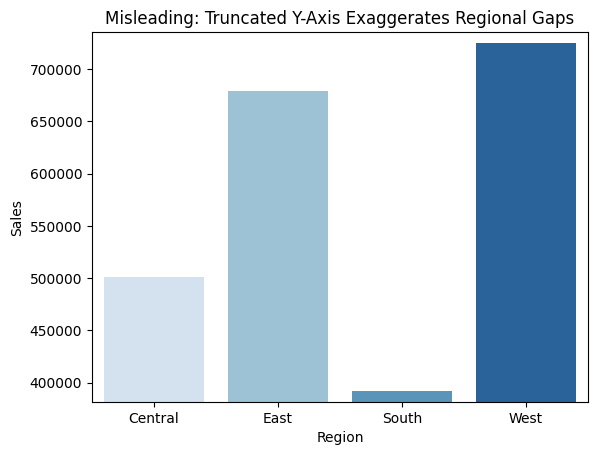

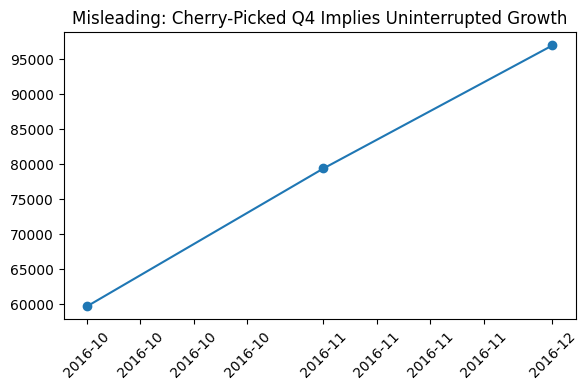

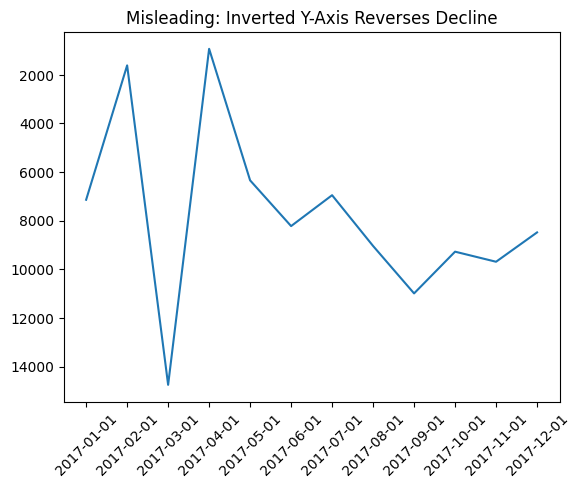

In [29]:
# 1. Truncated y-axis (Exaggerates differences)
plt.figure()
sns.barplot(data=region_sales, x='Region', y='Sales', palette='Blues')
plt.ylim(region_sales['Sales'].min() - 10000, region_sales['Sales'].max() + 10000)
plt.title('Misleading: Truncated Y-Axis Exaggerates Regional Gaps')

# 2. Cherry-picked date window (Hides true trend)
subset = monthly_sales[(monthly_sales['Order Date'] >= '2016-10') & (monthly_sales['Order Date'] <= '2016-12')]

plt.figure(figsize=(6, 4))
plt.plot(subset['Order Date'], subset['Sales'], marker='o')
plt.title('Misleading: Cherry-Picked Q4 Implies Uninterrupted Growth')

# Fixes applied here:
plt.xticks(rotation=45) # Rotates the text to prevent horizontal smearing
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Strips the days/times to just show the month
plt.tight_layout() # Ensures the rotated labels are not cut off at the bottom of the image

# 3. Inverted y-axis (Reverses growth/decline)
plt.figure()
plt.plot(monthly_profit['Order Date'].astype(str)[-12:], monthly_profit['Profit'][-12:])
plt.gca().invert_yaxis()
plt.xticks(rotation=45)
plt.title('Misleading: Inverted Y-Axis Reverses Decline')
plt.show()

# **TASK 6**

/tmp/ipykernel_1959/1865452465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Discount', y='Profit', palette='coolwarm')


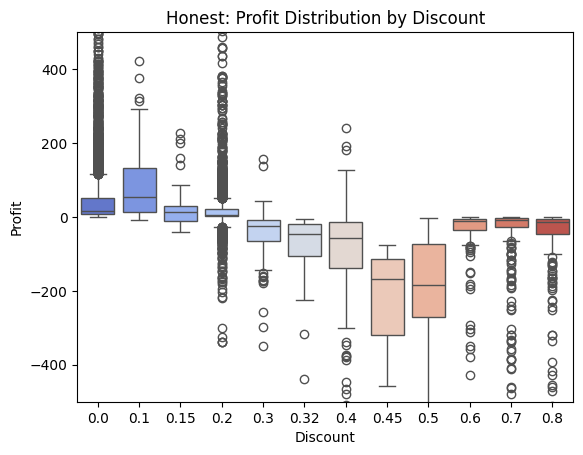

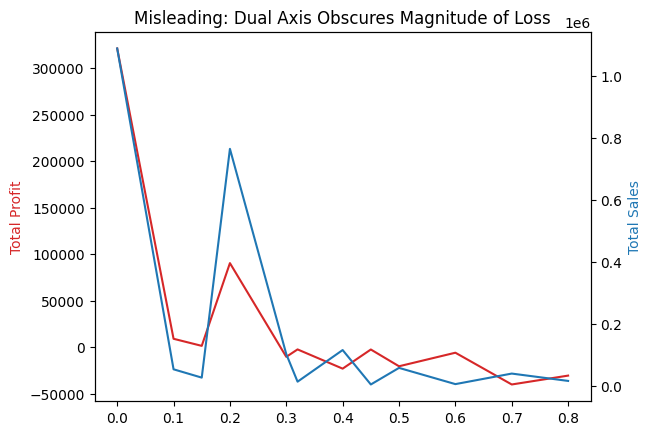

In [ ]:
# Honest
plt.figure()
sns.boxplot(data=df, x='Discount', y='Profit', palette='coolwarm')
plt.ylim(-500, 500)
plt.title('Honest: Profit Distribution by Discount')
plt.show()

# Misleading
fig, ax1 = plt.subplots()
color1, color2 = 'tab:red', 'tab:blue'
df_grp = df.groupby('Discount')[['Profit', 'Sales']].sum().reset_index()

ax1.set_ylabel('Total Profit', color=color1)
ax1.plot(df_grp['Discount'], df_grp['Profit'], color=color1)

ax2 = ax1.twinx()
ax2.set_ylabel('Total Sales', color=color2)
ax2.plot(df_grp['Discount'], df_grp['Sales'], color=color2)
plt.title('Misleading: Dual Axis Obscures Magnitude of Loss')
plt.show()